# Linear and logistic regression: real estate valuation

This notebook builds two models from the [UCI Real Estate Valuation dataset](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set):

1. a linear regression model for the continuous house price of unit area;
2. a logistic regression model for whether the price is above the training-set average.

The analysis is organised using the six CRISP-DM stages.

## 1. Business understanding

The continuous model is useful when an estimated price level is needed. The binary model answers a simpler question: does a property look more expensive than the average property seen during training?

Useful validation should answer more than “does the model run?” For linear regression I use MAE, RMSE, and $R^2$. For logistic regression I use a confusion matrix, accuracy, balanced accuracy, precision, recall, F1, and ROC AUC. I also compare both models with simple baselines and inspect which features matter most.

The dataset is small and observational. The results describe predictive relationships, not proof that changing one feature will cause the price to change.

## 2. Data understanding

### 2.1 Setup and loading

The imports are collected in one place. `find_data_file` checks several relative paths, so the notebook works when opened from the repository root, the `dkko` folder, or the assignments folder. Fixed random states make the train/test split and importance estimates repeatable.

In [1]:
import os
import tempfile
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "mplconfig_regression_assignment"))

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


def find_data_file(filename):
    candidates = [
        Path("dkko/datasets/real_estate") / filename,
        Path("datasets/real_estate") / filename,
        Path("../datasets/real_estate") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")


data_path = find_data_file("Real estate valuation data set.xlsx")
print("Data file:", data_path)

Data file: datasets\real_estate\Real estate valuation data set.xlsx


The original column names are fairly long, so I rename them after reading the Excel file. `No` is only a row identifier and is not a property characteristic.

In [2]:
raw = pd.read_excel(data_path)

column_names = {
    "X1 transaction date": "transaction_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "distance_to_mrt",
    "X4 number of convenience stores": "convenience_stores",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "price_per_unit_area",
}

data = raw.rename(columns=column_names).drop(columns="No")

print(f"Rows: {len(data):,}")
print(f"Columns used for modelling: {data.shape[1]}")
display(data.head())

Rows: 414
Columns used for modelling: 7


,transaction_date,house_age,distance_to_mrt,convenience_stores,latitude,longitude,price_per_unit_area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### 2.2 Quality and descriptive checks

The next cell checks missing values, duplicate full rows, and numerical ranges. Duplicate rows are not automatically an error in housing data because two transactions can share the same measurements. The important checks here are that every modelling value is numeric and no value is missing.

In [3]:
quality = pd.Series({
    "rows": len(data),
    "missing values": int(data.isna().sum().sum()),
    "duplicate full rows": int(data.duplicated().sum()),
    "non-numeric columns": int((~data.dtypes.apply(pd.api.types.is_numeric_dtype)).sum()),
})

display(quality.to_frame("value"))
display(data.describe().T.round(3))

,value
rows,414
missing values,0
duplicate full rows,0
non-numeric columns,0


,count,mean,std,min,25%,50%,75%,max
transaction_date,414.0,2013.149,0.282,2012.667,2012.917,2013.167,2013.417,2013.583
house_age,414.0,17.713,11.392,0.000,9.025,16.100,28.150,43.800
distance_to_mrt,414.0,1083.886,1262.110,23.383,289.325,492.231,1454.279,6488.021
convenience_stores,414.0,4.094,2.946,0.000,1.000,4.000,6.000,10.000
latitude,414.0,24.969,0.012,24.932,24.963,24.971,24.977,25.015
longitude,414.0,121.533,0.015,121.474,121.528,121.539,121.543,121.566
price_per_unit_area,414.0,37.980,13.606,7.600,27.700,38.450,46.600,117.500


The target distribution contains a few high-price observations, including one clear extreme value. That can increase RMSE because squared errors give unusual cases a large weight. MAE is reported as well because it is easier to interpret as the typical absolute error and is less sensitive to a single extreme case.

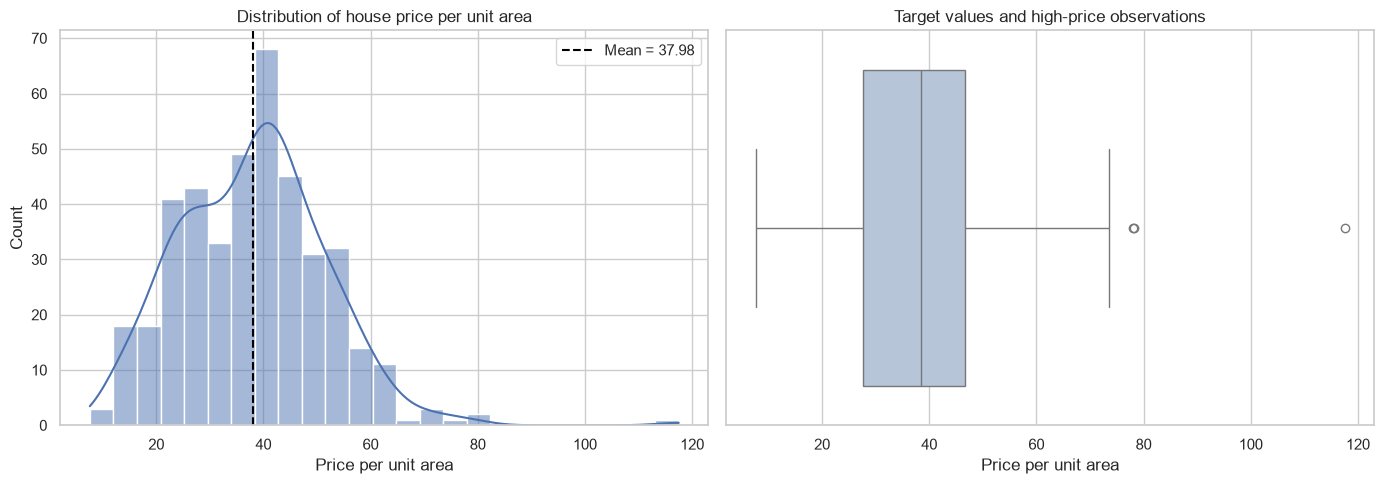

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=data, x="price_per_unit_area", bins=25, kde=True, ax=axes[0])
axes[0].axvline(
    data["price_per_unit_area"].mean(),
    color="black",
    linestyle="--",
    label=f"Mean = {data['price_per_unit_area'].mean():.2f}",
)
axes[0].set(title="Distribution of house price per unit area", xlabel="Price per unit area")
axes[0].legend()

sns.boxplot(data=data, x="price_per_unit_area", ax=axes[1], color="lightsteelblue")
axes[1].set(title="Target values and high-price observations", xlabel="Price per unit area")

plt.tight_layout()
plt.show()

Correlations give a first view of the relationships. They do not replace the models, but they help spot linear trends and multicollinearity. In particular, MRT distance and longitude are strongly related. This can make individual coefficients unstable because the model has two overlapping ways to describe location.

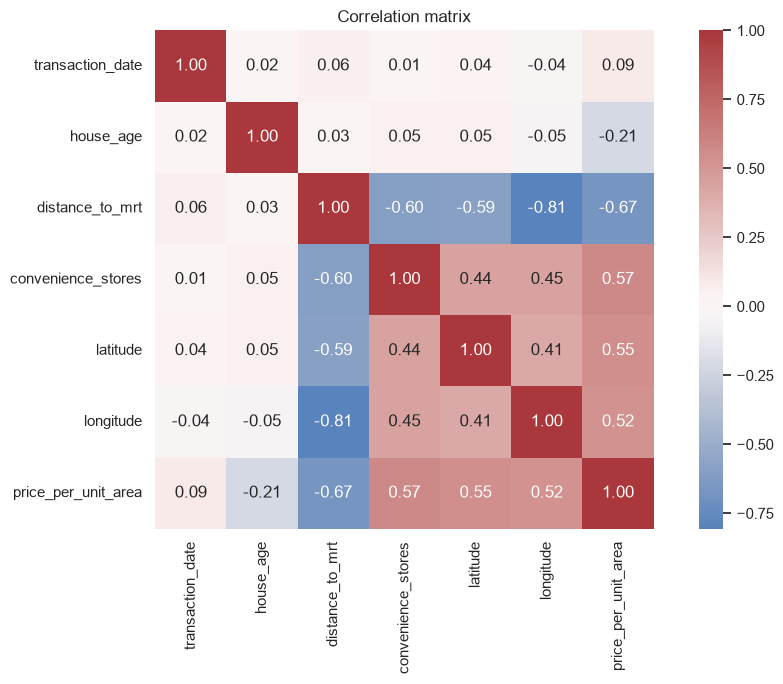

In [5]:
correlations = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

The scatterplots show the three clearest simple relationships. Prices generally fall as MRT distance or house age increases, and they tend to rise when more convenience stores are nearby. The wide vertical spread also suggests that a straight-line model will not explain every transaction.

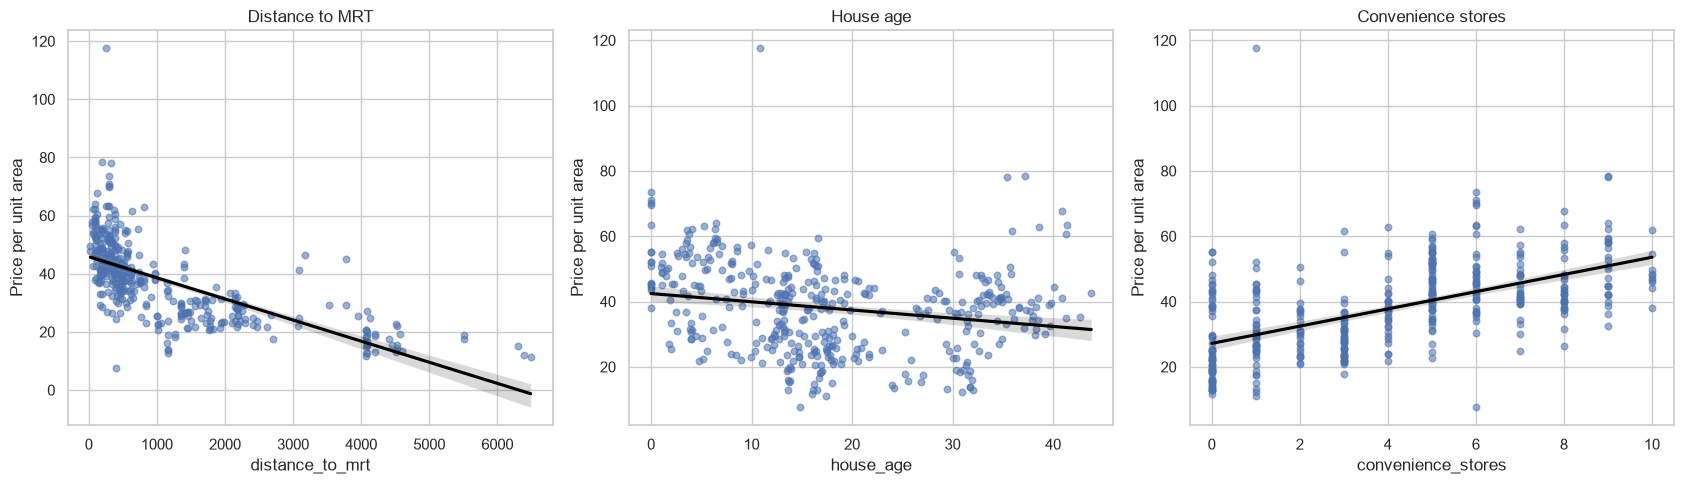

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feature, title in [
    (axes[0], "distance_to_mrt", "Distance to MRT"),
    (axes[1], "house_age", "House age"),
    (axes[2], "convenience_stores", "Convenience stores"),
]:
    sns.regplot(
        data=data,
        x=feature,
        y="price_per_unit_area",
        scatter_kws={"s": 22, "alpha": 0.55},
        line_kws={"color": "black"},
        ax=ax,
    )
    ax.set(title=title, ylabel="Price per unit area")

plt.tight_layout()
plt.show()

## 3. Data preparation

The same 80/20 split is used for both tasks. Splitting before calculating the logistic cutoff is important: using the full-data average would let the held-out test prices influence the target definition.

Standardisation is placed inside each model pipeline. The scaler is therefore fitted only on training folds. Scaling is not required for unregularised linear regression to make predictions, but it lets us compare coefficient sizes. It is more important for scikit-learn's logistic regression because the default L2 regularisation should treat all features on a comparable scale.

In [7]:
FEATURES = [
    "transaction_date",
    "house_age",
    "distance_to_mrt",
    "convenience_stores",
    "latitude",
    "longitude",
]
TARGET = "price_per_unit_area"

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# The binary cutoff comes from training prices only.
training_mean_price = y_train.mean()
y_train_high = (y_train > training_mean_price).astype(int)
y_test_high = (y_test > training_mean_price).astype(int)

split_summary = pd.DataFrame({
    "set": ["Training", "Test"],
    "rows": [len(X_train), len(X_test)],
    "mean_continuous_price": [y_train.mean(), y_test.mean()],
    "below_or_equal_average": [(y_train_high == 0).sum(), (y_test_high == 0).sum()],
    "above_average": [(y_train_high == 1).sum(), (y_test_high == 1).sum()],
})

print(f"Training-set mean used as the logistic cutoff: {training_mean_price:.2f}")
display(split_summary.round(2))

Training-set mean used as the logistic cutoff: 38.39


,set,rows,mean_continuous_price,below_or_equal_average,above_average
0,Training,331,38.39,157,174
1,Test,83,36.34,48,35


## 4. Modelling

### 4.1 Linear regression

The pipeline first standardises each predictor and then fits ordinary least squares regression. A coefficient now means the predicted price change associated with a one-standard-deviation increase in that feature, while the other features stay fixed.

In [8]:
linear_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_coefficients = pd.DataFrame({
    "feature": FEATURES,
    "standardized_coefficient": linear_model.named_steps["model"].coef_,
})
linear_coefficients["absolute_coefficient"] = linear_coefficients["standardized_coefficient"].abs()
linear_coefficients = linear_coefficients.sort_values("absolute_coefficient", ascending=False)

print(f"Intercept (price at average feature values): {linear_model.named_steps['model'].intercept_:.2f}")
display(linear_coefficients.round(3))

Intercept (price at average feature values): 38.39


,feature,standardized_coefficient,absolute_coefficient
2,distance_to_mrt,-5.787,5.787
3,convenience_stores,3.219,3.219
1,house_age,-3.063,3.063
4,latitude,2.855,2.855
0,transaction_date,1.530,1.530
5,longitude,-0.441,0.441


### 4.2 Logistic regression

Class 1 means that the observed price is above the training mean; class 0 means it is at or below that mean. Logistic regression estimates the probability of class 1. The default decision threshold is 0.5.

Because the predictors are standardised, exponentiating a coefficient gives the change in the odds of an above-average price for a one-standard-deviation increase in that feature, conditional on the other inputs.

In [9]:
logistic_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

logistic_model.fit(X_train, y_train_high)
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

logistic_coefficients = pd.DataFrame({
    "feature": FEATURES,
    "standardized_log_odds_coefficient": logistic_model.named_steps["model"].coef_[0],
})
logistic_coefficients["odds_ratio_per_1_sd"] = np.exp(
    logistic_coefficients["standardized_log_odds_coefficient"]
)
logistic_coefficients["absolute_coefficient"] = logistic_coefficients[
    "standardized_log_odds_coefficient"
].abs()
logistic_coefficients = logistic_coefficients.sort_values("absolute_coefficient", ascending=False)

display(logistic_coefficients.round(3))

,feature,standardized_log_odds_coefficient,odds_ratio_per_1_sd,absolute_coefficient
2,distance_to_mrt,-2.332,0.097,2.332
4,latitude,0.946,2.574,0.946
1,house_age,-0.608,0.544,0.608
3,convenience_stores,0.551,1.736,0.551
0,transaction_date,0.234,1.263,0.234
5,longitude,-0.141,0.868,0.141


## 5. Evaluation

### 5.1 Linear regression evaluation

The held-out model is compared with a baseline that predicts the training mean for every test property. RMSE is the square root of mean squared error, so it is in the same price units as MAE and the target.

In [10]:
baseline_linear_predictions = np.repeat(y_train.mean(), len(y_test))

linear_metrics = pd.DataFrame({
    "model": ["Linear regression", "Training-mean baseline"],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, baseline_linear_predictions),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, baseline_linear_predictions)),
    ],
    "R2": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, baseline_linear_predictions),
    ],
})

display(linear_metrics.round(3))

,model,MAE,RMSE,R2
0,Linear regression,5.305,7.315,0.681
1,Training-mean baseline,10.917,13.114,-0.025


On the held-out set, the model's MAE is about 5.31 price units and $R^2$ is about 0.68. The baseline MAE is about 10.92, so the fitted model roughly halves the typical absolute error. RMSE is higher than MAE, which is consistent with a few large misses.

Since 414 rows is not a large dataset, the next cell also performs shuffled five-fold cross-validation. Each fold fits its own scaler and model. This gives a better view of how performance changes with a different validation sample.

In [11]:
linear_cv = cross_validate(
    Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    X,
    y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
)

linear_cv_results = pd.DataFrame({
    "fold": range(1, 6),
    "MAE": -linear_cv["test_MAE"],
    "RMSE": -linear_cv["test_RMSE"],
    "R2": linear_cv["test_R2"],
})

display(linear_cv_results.round(3))
display(
    linear_cv_results.agg(["mean", "std"])[["MAE", "RMSE", "R2"]].round(3)
)

,fold,MAE,RMSE,R2
0,1,5.305,7.315,0.681
1,2,6.115,8.603,0.437
2,3,6.281,8.224,0.633
3,4,6.530,8.582,0.606
4,5,6.868,11.256,0.490


,MAE,RMSE,R2
mean,6.220,8.796,0.569
std,0.585,1.471,0.102


The actual-versus-predicted plot shows how closely points follow the ideal diagonal. The residual is `actual - predicted`: positive values are underpredictions and negative values are overpredictions. A useful linear model should leave residuals without a clear curve or funnel shape.

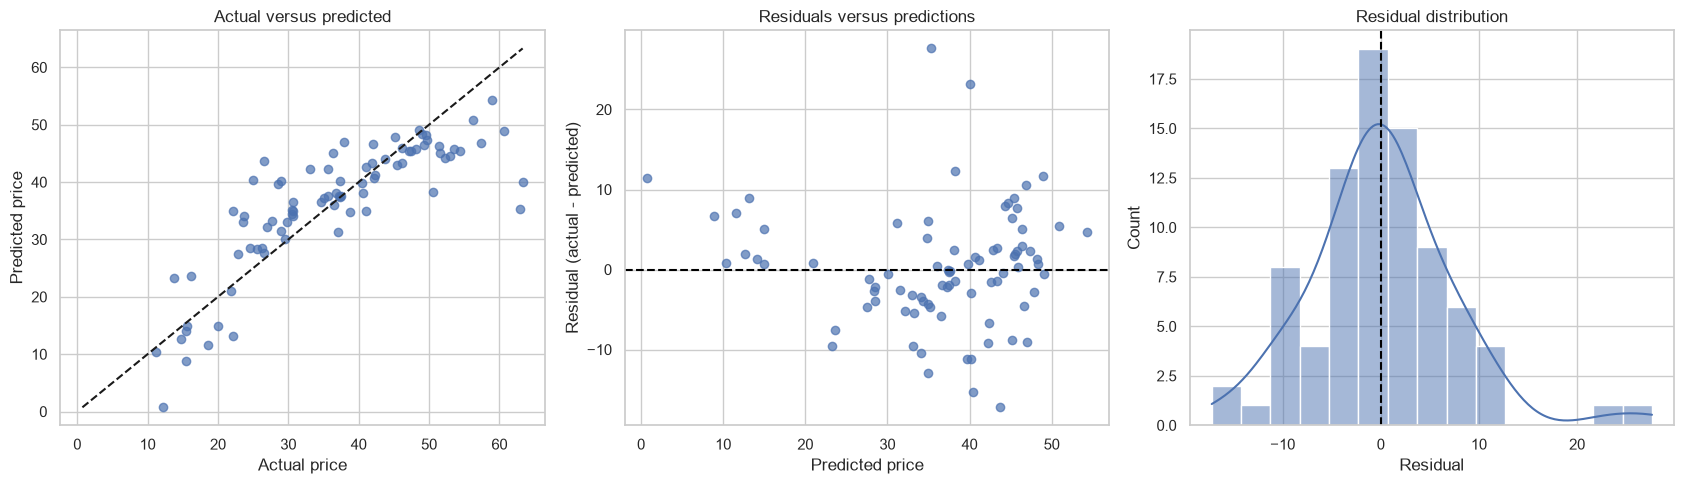

In [12]:
linear_residuals = y_test.to_numpy() - linear_predictions

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(y_test, linear_predictions, alpha=0.7)
limit_low = min(y_test.min(), linear_predictions.min())
limit_high = max(y_test.max(), linear_predictions.max())
axes[0].plot([limit_low, limit_high], [limit_low, limit_high], "k--")
axes[0].set(
    title="Actual versus predicted",
    xlabel="Actual price",
    ylabel="Predicted price",
)

axes[1].scatter(linear_predictions, linear_residuals, alpha=0.7)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(
    title="Residuals versus predictions",
    xlabel="Predicted price",
    ylabel="Residual (actual - predicted)",
)

sns.histplot(linear_residuals, bins=15, kde=True, ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set(title="Residual distribution", xlabel="Residual")

plt.tight_layout()
plt.show()

Most predictions are reasonably close to the diagonal, but several large positive and negative residuals remain. The residual distribution is centred near zero but not perfectly normal, and the model tends to pull extreme prices toward the middle. The linear model is useful as a baseline, but the diagnostics suggest that location effects and price relationships are not completely linear.

Coefficient magnitude is one view of importance. Permutation importance gives a second view by shuffling one test feature at a time and measuring the increase in MAE. It is calculated only on the held-out set.

,feature,MAE_increase_when_shuffled,importance_std
2,distance_to_mrt,4.074,0.511
1,house_age,1.445,0.306
3,convenience_stores,1.254,0.297
4,latitude,0.839,0.269
0,transaction_date,0.198,0.116
5,longitude,0.045,0.055


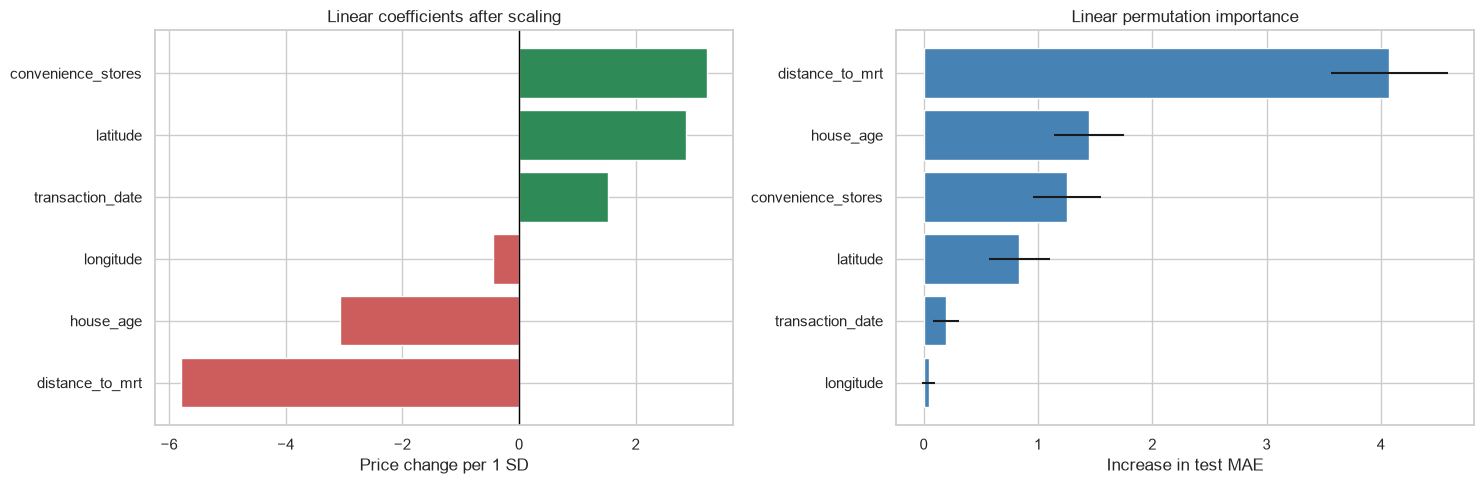

In [13]:
linear_permutation = permutation_importance(
    linear_model,
    X_test,
    y_test,
    n_repeats=50,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

linear_importance = pd.DataFrame({
    "feature": FEATURES,
    "MAE_increase_when_shuffled": linear_permutation.importances_mean,
    "importance_std": linear_permutation.importances_std,
}).sort_values("MAE_increase_when_shuffled", ascending=False)

display(linear_importance.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

coefficient_plot = linear_coefficients.sort_values("standardized_coefficient")
axes[0].barh(
    coefficient_plot["feature"],
    coefficient_plot["standardized_coefficient"],
    color=np.where(coefficient_plot["standardized_coefficient"] >= 0, "seagreen", "indianred"),
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(title="Linear coefficients after scaling", xlabel="Price change per 1 SD")

importance_plot = linear_importance.sort_values("MAE_increase_when_shuffled")
axes[1].barh(
    importance_plot["feature"],
    importance_plot["MAE_increase_when_shuffled"],
    xerr=importance_plot["importance_std"],
    color="steelblue",
)
axes[1].set(title="Linear permutation importance", xlabel="Increase in test MAE")

plt.tight_layout()
plt.show()

Both approaches identify **distance to the nearest MRT station** as the strongest predictor. Greater distance has a clear negative relationship with price. House age, nearby convenience stores, and latitude form the next group. Transaction date has a smaller contribution, and longitude adds very little once the other location variables are present.

Longitude's weak conditional importance does not mean that geography is unimportant. It is strongly correlated with MRT distance, so its information is partly redundant. This multicollinearity is also why coefficient signs should not be read as causal effects.

### 5.2 Logistic regression evaluation

The majority-class baseline always predicts the more common test class. Balanced accuracy is included because the test classes are not exactly equal. ROC AUC evaluates the probability ranking across all possible decision thresholds rather than only the default 0.5 cutoff.

In [14]:
majority_accuracy = y_test_high.value_counts(normalize=True).max()

logistic_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision (above average)",
        "Recall (above average)",
        "F1 (above average)",
        "ROC AUC",
        "Majority-class baseline accuracy",
    ],
    "value": [
        accuracy_score(y_test_high, logistic_predictions),
        balanced_accuracy_score(y_test_high, logistic_predictions),
        precision_score(y_test_high, logistic_predictions),
        recall_score(y_test_high, logistic_predictions),
        f1_score(y_test_high, logistic_predictions),
        roc_auc_score(y_test_high, logistic_probabilities),
        majority_accuracy,
    ],
})

display(logistic_metrics.round(3))
print(classification_report(
    y_test_high,
    logistic_predictions,
    target_names=["At/below average", "Above average"],
))

,metric,value
0,Accuracy,0.819
1,Balanced accuracy,0.832
2,Precision (above average),0.727
3,Recall (above average),0.914
4,F1 (above average),0.810
5,ROC AUC,0.924
6,Majority-class baseline accuracy,0.578


                  precision    recall  f1-score   support

At/below average       0.92      0.75      0.83        48
   Above average       0.73      0.91      0.81        35

        accuracy                           0.82        83
       macro avg       0.83      0.83      0.82        83
    weighted avg       0.84      0.82      0.82        83



The held-out accuracy is about 0.82 compared with a 0.58 majority baseline. ROC AUC is about 0.92, so the probability ranking is strong. Above-average recall is high (about 0.91), meaning only a few genuinely above-average properties are missed. Precision is lower (about 0.73), so some ordinary properties are labelled above average.

The confusion matrix shows those errors directly, while the ROC curve shows the trade-off between true-positive and false-positive rates.

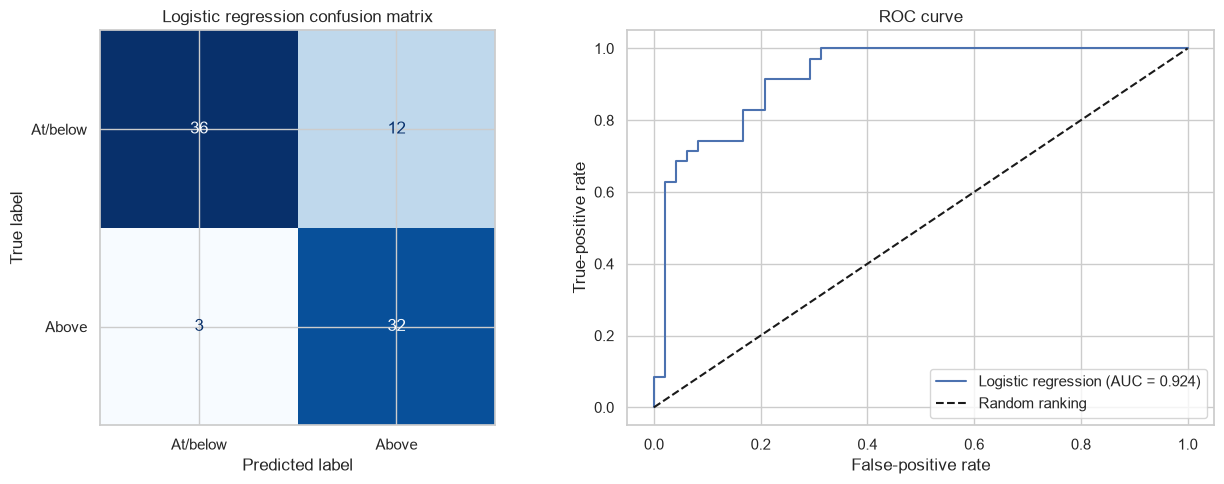

In [15]:
cm = confusion_matrix(y_test_high, logistic_predictions)
fpr, tpr, _ = roc_curve(y_test_high, logistic_probabilities)
auc_value = roc_auc_score(y_test_high, logistic_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["At/below", "Above"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic regression confusion matrix")

axes[1].plot(fpr, tpr, label=f"Logistic regression (AUC = {auc_value:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random ranking")
axes[1].set(
    title="ROC curve",
    xlabel="False-positive rate",
    ylabel="True-positive rate",
)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Five-fold cross-validation is performed on the training portion only. The held-out test set remains untouched, while the folds show whether the result depends heavily on one particular training subset.

In [16]:
logistic_cv = cross_validate(
    Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    X_train,
    y_train_high,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "F1": "f1",
        "ROC_AUC": "roc_auc",
    },
)

logistic_cv_results = pd.DataFrame({
    "fold": range(1, 6),
    "accuracy": logistic_cv["test_accuracy"],
    "balanced_accuracy": logistic_cv["test_balanced_accuracy"],
    "F1": logistic_cv["test_F1"],
    "ROC_AUC": logistic_cv["test_ROC_AUC"],
})

display(logistic_cv_results.round(3))
display(
    logistic_cv_results.agg(["mean", "std"])[
        ["accuracy", "balanced_accuracy", "F1", "ROC_AUC"]
    ].round(3)
)

,fold,accuracy,balanced_accuracy,F1,ROC_AUC
0,1,0.821,0.817,0.842,0.895
1,2,0.773,0.764,0.810,0.888
2,3,0.758,0.753,0.784,0.908
3,4,0.924,0.923,0.930,0.974
4,5,0.818,0.816,0.833,0.902


,accuracy,balanced_accuracy,F1,ROC_AUC
mean,0.819,0.814,0.840,0.913
std,0.065,0.067,0.055,0.035


The coefficient and permutation views below again agree on the main result. Logistic permutation importance is the mean decrease in test ROC AUC when a feature is shuffled. Odds ratios describe direction and size in the fitted model, while permutation importance measures the feature's contribution to held-out predictions.

,feature,ROC_AUC_decrease_when_shuffled,importance_std
2,distance_to_mrt,0.238,0.057
1,house_age,0.059,0.018
4,latitude,0.038,0.023
3,convenience_stores,0.034,0.014
0,transaction_date,0.009,0.006
5,longitude,0.000,0.004


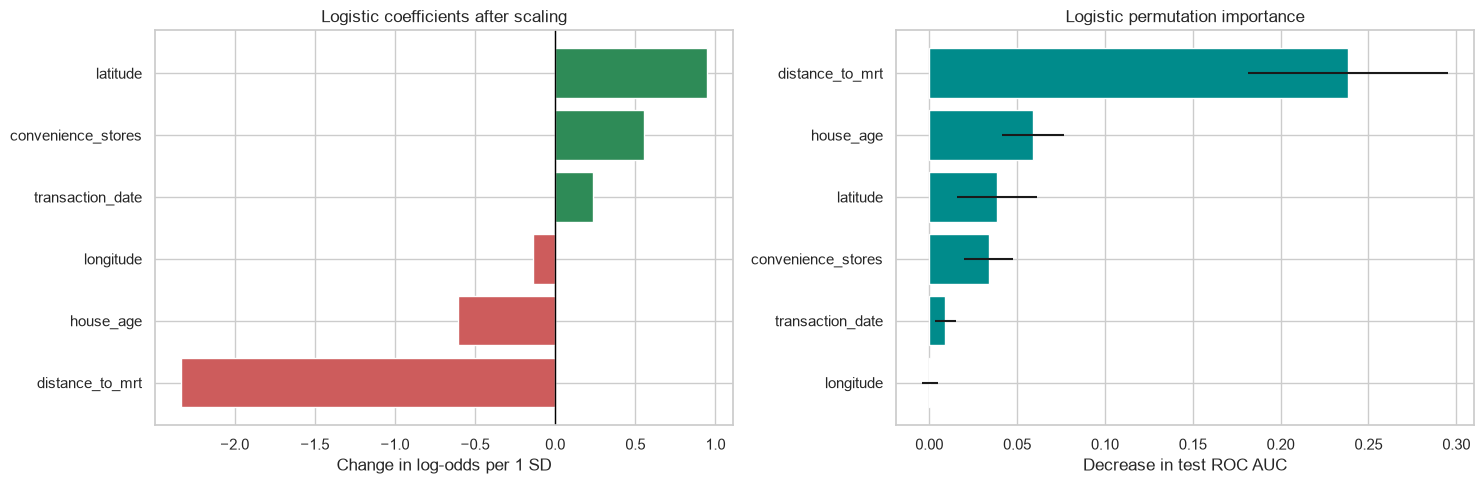

In [17]:
logistic_permutation = permutation_importance(
    logistic_model,
    X_test,
    y_test_high,
    n_repeats=50,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

logistic_importance = pd.DataFrame({
    "feature": FEATURES,
    "ROC_AUC_decrease_when_shuffled": logistic_permutation.importances_mean,
    "importance_std": logistic_permutation.importances_std,
}).sort_values("ROC_AUC_decrease_when_shuffled", ascending=False)

display(logistic_importance.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

log_coefficient_plot = logistic_coefficients.sort_values("standardized_log_odds_coefficient")
axes[0].barh(
    log_coefficient_plot["feature"],
    log_coefficient_plot["standardized_log_odds_coefficient"],
    color=np.where(
        log_coefficient_plot["standardized_log_odds_coefficient"] >= 0,
        "seagreen",
        "indianred",
    ),
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set(title="Logistic coefficients after scaling", xlabel="Change in log-odds per 1 SD")

log_importance_plot = logistic_importance.sort_values("ROC_AUC_decrease_when_shuffled")
axes[1].barh(
    log_importance_plot["feature"],
    log_importance_plot["ROC_AUC_decrease_when_shuffled"],
    xerr=log_importance_plot["importance_std"],
    color="darkcyan",
)
axes[1].set(title="Logistic permutation importance", xlabel="Decrease in test ROC AUC")

plt.tight_layout()
plt.show()

MRT distance is by far the most important feature in the classifier as well. Its odds ratio is around 0.10 per standard deviation, so greater distance sharply lowers the fitted odds of an above-average price. Latitude, house age, and convenience stores have smaller but visible contributions. Transaction date and longitude are the weakest conditional predictors in this model.

The exact coefficient values should not be treated as permanent market effects. They come from a small dataset collected in one area and period, and correlated location variables share predictive information.

## 6. Deployment

The linear model can be used as a simple price benchmark, with a typical held-out error of about 5.3 price units. The logistic model is suitable for screening properties into “likely above average” and “likely at or below average,” using the saved training cutoff of 38.39. The cutoff and fitted scaler must travel with the model; recalculating the cutoff from future test cases would change the meaning of the class.

For practical use I would:

1. show predictions as estimates with uncertainty, not exact valuations;
2. monitor MAE, ROC AUC, and class balance on new transactions;
3. retrain when the market level or geographic coverage changes;
4. keep MRT distance as a core feature and collect richer location, size, floor, and property-condition data;
5. test nonlinear models because the residual plots show that a straight-line relationship is only an approximation.

Overall, both models clearly beat their baselines. Distance to the nearest MRT station is the most useful predictor in both tasks. House age, convenience stores, and latitude also matter, while transaction date and longitude contribute less after the other variables are considered. Standardisation is mainly useful for fair coefficient comparison in linear regression and is important for the regularised logistic model.